# Semi-Gradient TD with Linear Function Approximation

This notebook demonstrates **why semi-gradient methods work** when approximating value functions in Reinforcement Learning.

We consider a **continuous state space** and approximate the value function using **linear regression features**.

Value function approximation:

$$ V(s, w) = w^T x(s) $$

Semi-gradient TD update rule:

$$ w \leftarrow w + \alpha (r + \gamma V(s',w) - V(s,w)) x(s) $$

Key idea: instead of storing values for every state, we **learn parameters (weights)** that generalize across states.

## Step 1: Create a Simple Continuous Environment

We create a simple 1D random walk with continuous states between **-1 and 1**.

In [1]:
import numpy as np

class ContinuousRandomWalk:
    def __init__(self):
        self.state = 0.0

    def reset(self):
        self.state = np.random.uniform(-0.5,0.5)
        return self.state

    def step(self):
        move = np.random.uniform(-0.1,0.1)
        self.state += move

        reward = 0
        done = False

        if self.state >= 1:
            reward = 1
            done = True

        if self.state <= -1:
            reward = -1
            done = True

        return self.state, reward, done

## Step 2: Linear Feature Representation

We convert a scalar state into a **feature vector**:

$$ x(s) = [1, s, s^2] $$

The bias term allows the model to shift the value function.

In [2]:
def features(s):
    return np.array([1, s, s**2])

## Step 3: Initialize Parameters

In [3]:
alpha = 0.05
gamma = 0.9
episodes = 200

w = np.zeros(3)

## Step 4: Semi‑Gradient TD Learning

In [ ]:
env = ContinuousRandomWalk()

def value(s):
    return np.dot(w, features(s))

history = []

for ep in range(episodes):
    s = env.reset()
    done = False

    while not done:
        s_next, r, done = env.step()

        v = value(s)
        v_next = value(s_next)

        delta = r + gamma * v_next - v

        w[:] = w + alpha * delta * features(s)

        s = s_next

    history.append(np.linalg.norm(w))



array([-0.00568154,  0.34161027, -0.05478083])

## Step 5: Observe Parameter Convergence

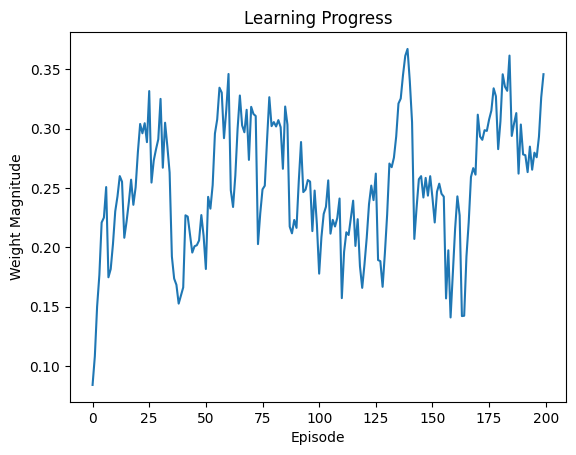

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history)
plt.xlabel("Episode")
plt.ylabel("Weight Magnitude")
plt.title("Learning Progress")
plt.show()

## Step 6: Visualize the Learned Value Function

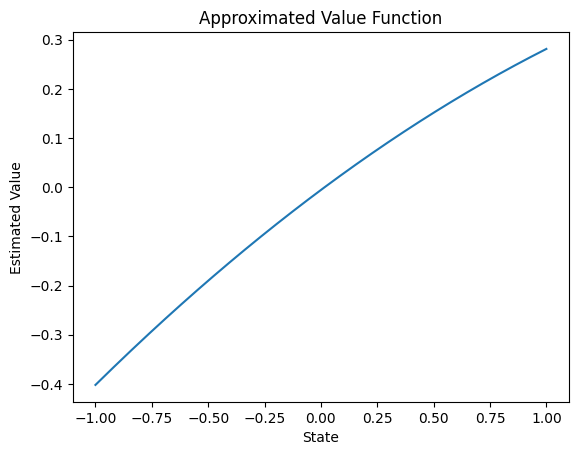

In [6]:
states = np.linspace(-1,1,200)
values = [value(s) for s in states]

plt.figure()
plt.plot(states, values)
plt.xlabel("State")
plt.ylabel("Estimated Value")
plt.title("Approximated Value Function")
plt.show()

## Key Takeaways

1. Semi‑gradient methods update parameters using the **TD error**.
2. The gradient is taken with respect to **V(s,w)** only.
3. This allows learning even when the **state space is continuous**.
4. Linear function approximation is the simplest example of **value function approximation**.

This idea forms the basis for **Deep Q Networks and Actor‑Critic methods**, where the linear model is replaced by neural networks.